# Process Design Enhancements — Absorbers, Water Treatment & Erosion

This notebook demonstrates new NeqSim process design features:

1. **TEG Absorber Fs-factor sizing** — capacity check for structured packing
2. **Amine absorber gas sweetening** — CO2/H2S removal with design validation
3. **Gas flotation unit (IGF/DGF)** — multi-stage produced water treatment
4. **Hydrocyclone design validation** — dP adequacy and efficiency estimation
5. **Erosion sand load defaults** — completion-type-based screening

All equipment integrates with `ProcessSystem` for full flowsheet simulation.

In [1]:
# Setup and imports
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim3\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim3\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim3\target\neqsim-3.7.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [4]:
import jpype
import matplotlib.pyplot as plt
import numpy as np

JClass = jpype.JClass

if NEQSIM_MODE == "pip":
    from neqsim import jneqsim
    SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
    ProcessSystem = jneqsim.process.processmodel.ProcessSystem
    Stream = jneqsim.process.equipment.stream.Stream
    SimpleTEGAbsorber = jneqsim.process.equipment.absorber.SimpleTEGAbsorber
    SimpleAmineAbsorber = jneqsim.process.equipment.absorber.SimpleAmineAbsorber
    GasFlotationUnit = jneqsim.process.equipment.watertreatment.GasFlotationUnit
    Hydrocyclone = jneqsim.process.equipment.watertreatment.Hydrocyclone
else:
    SystemSrkEos = ns.SystemSrkEos
    ProcessSystem = ns.ProcessSystem
    Stream = ns.Stream
    SimpleTEGAbsorber = JClass("neqsim.process.equipment.absorber.SimpleTEGAbsorber")
    SimpleAmineAbsorber = JClass("neqsim.process.equipment.absorber.SimpleAmineAbsorber")
    GasFlotationUnit = JClass("neqsim.process.equipment.watertreatment.GasFlotationUnit")
    Hydrocyclone = JClass("neqsim.process.equipment.watertreatment.Hydrocyclone")

ErosionPredictionCalculator = JClass("neqsim.pvtsimulation.flowassurance.ErosionPredictionCalculator")

print("All classes loaded successfully")

All classes loaded successfully


## 1. TEG Absorber — Fs-Factor Sizing

The Fs-factor determines whether the contactor diameter is adequate for the gas load:

$$F_s = v_s \cdot \sqrt{\rho_g}$$

Industry practice limits Fs to approximately 2.5–3.5 (Pa)$^{0.5}$ for structured packing.

In [5]:
# Create wet gas fluid
wet_gas = SystemSrkEos(273.15 + 30.0, 70.0)
wet_gas.addComponent("methane", 0.90)
wet_gas.addComponent("ethane", 0.05)
wet_gas.addComponent("propane", 0.02)
wet_gas.addComponent("water", 0.03)
wet_gas.setMixingRule("classic")

gas_feed = Stream("Wet Gas Feed", wet_gas)
gas_feed.setFlowRate(5000000.0, "Sm3/day")

# Create lean TEG
teg_fluid = SystemSrkEos(273.15 + 35.0, 70.0)
teg_fluid.addComponent("TEG", 0.995)
teg_fluid.addComponent("water", 0.005)
teg_fluid.setMixingRule("classic")

lean_teg = Stream("Lean TEG", teg_fluid)
lean_teg.setFlowRate(3000.0, "kg/hr")

# TEG contactor
teg_absorber = SimpleTEGAbsorber("TEG Contactor")
teg_absorber.addGasInStream(gas_feed)
teg_absorber.addSolventInStream(lean_teg)
teg_absorber.setNumberOfStages(3)
teg_absorber.setStageEfficiency(0.5)

process = ProcessSystem()
process.add(gas_feed)
process.add(lean_teg)
process.add(teg_absorber)
process.run()

# Fs-factor results
fs = teg_absorber.getFsFactor()
max_fs = teg_absorber.getMaxAllowableFsFactor()
within_limit = teg_absorber.isFsFactorWithinDesignLimit()
utilization = teg_absorber.getFsFactorUtilization()
min_diameter = teg_absorber.getMinimumDiameterForFsLimit()

print(f"Fs-factor:           {float(fs):.3f} (Pa)^0.5")
print(f"Max allowable:       {float(max_fs):.1f} (Pa)^0.5")
print(f"Within design limit: {bool(within_limit)}")
print(f"Utilization:         {float(utilization)*100:.1f}%")
print(f"Min diameter for Fs: {float(min_diameter):.3f} m")
print()
print(str(teg_absorber.validateContactorDesign()))

Fs-factor:           7.271 (Pa)^0.5
Max allowable:       3.0 (Pa)^0.5
Within design limit: False
Utilization:         242.4%
Min diameter for Fs: 1.557 m

TEG Contactor Design Validation
Fs factor: 7.271 m/s*sqrt(kg/m3) (max: 3.0)
Fs utilization: 242.4%
Fs within limit: EXCEEDED
Minimum diameter needed: 1.557 m
Gas load factor (Ks): NaN m/s
NTU: 2.00
Number of theoretical stages: 3.00



## 2. Amine Absorber — Gas Sweetening

The `SimpleAmineAbsorber` models CO2/H2S removal using amine solvents. This example removes
CO2 from a sour gas stream with MDEA, then validates the absorber design.

In [6]:
# Create sour gas with CO2 and H2S
sour_gas = SystemSrkEos(273.15 + 40.0, 70.0)
sour_gas.addComponent("methane", 0.82)
sour_gas.addComponent("ethane", 0.05)
sour_gas.addComponent("CO2", 0.10)
sour_gas.addComponent("H2S", 0.01)
sour_gas.addComponent("nitrogen", 0.02)
sour_gas.setMixingRule("classic")

sour_feed = Stream("Sour Gas Feed", sour_gas)
sour_feed.setFlowRate(80000.0, "kg/hr")

# Amine absorber
amine_abs = SimpleAmineAbsorber("MDEA Absorber", sour_feed)
amine_abs.setAmineType("MDEA")
amine_abs.setAmineConcentrationWtPct(50.0)
amine_abs.setCO2RemovalEfficiency(0.95)
amine_abs.setH2SRemovalEfficiency(0.99)
amine_abs.setFoamingDesignMargin(0.20)

# Wire into process
process2 = ProcessSystem()
process2.add(sour_feed)
process2.add(amine_abs)
process2.run()

# Results: CO2 in sweet gas vs feed
feed_system = sour_feed.getThermoSystem()
sweet_system = amine_abs.getSweetGasOutStream().getThermoSystem()

feed_co2 = float(feed_system.getPhase(0).getComponent("CO2").getNumberOfmoles())
sweet_co2 = float(sweet_system.getPhase(0).getComponent("CO2").getNumberOfmoles())
feed_h2s = float(feed_system.getPhase(0).getComponent("H2S").getNumberOfmoles())
sweet_h2s = float(sweet_system.getPhase(0).getComponent("H2S").getNumberOfmoles())

co2_removed_pct = (1 - sweet_co2 / feed_co2) * 100
h2s_removed_pct = (1 - sweet_h2s / feed_h2s) * 100

print(f"CO2 removal: {co2_removed_pct:.1f}% (target 95%)")
print(f"H2S removal: {h2s_removed_pct:.1f}% (target 99%)")
print(f"\nStream topology:")
print(f"  Inlet streams:  {len(list(amine_abs.getInletStreams()))}")
print(f"  Outlet streams: {len(list(amine_abs.getOutletStreams()))}")

CO2 removal: 95.0% (target 95%)
H2S removal: 99.0% (target 99%)

Stream topology:
  Inlet streams:  1
  Outlet streams: 1


In [7]:
# Design calculations
amine_abs.setLeanAmineLoading(0.01)
amine_abs.setApproachToEquilibrium(0.70)
rich_loading = float(amine_abs.calcRichAmineLoading(0.50))

circ_rate = float(amine_abs.calcRequiredCirculationRate(
    10.0,    # mol/s acid gas
    1050.0,  # kg/m3 amine density
    0.119    # kg/mol MDEA molar mass
))

amine_abs.setMaxPackingHeightPerSection(5.5)
amine_abs.calcPackingHeight(0.85, 10.0)  # HTU=0.85m, NTU=10
packing_height = float(amine_abs.getRequiredPackingHeight())
n_sections = int(amine_abs.getNumberOfPackingSections())

k_factor = float(amine_abs.calcDemisterKFactor(1.5, 30.0, 1050.0))
temp_ok = bool(amine_abs.checkAmineTemperatureMargin(40.0, 47.0))

print(f"Rich amine loading:     {rich_loading:.3f} mol/mol")
print(f"Circulation rate:       {circ_rate:.1f} m3/h")
print(f"Packing height:         {packing_height:.1f} m in {n_sections} sections")
print(f"Demister K-factor:      {k_factor:.4f} m/s (limit 0.08)")
print(f"Temperature margin OK:  {temp_ok}")
print()
print(str(amine_abs.getDesignSummary()))

Rich amine loading:     0.353 mol/mol
Circulation rate:       23.8 m3/h
Packing height:         8.5 m in 2 sections
Demister K-factor:      0.2572 m/s (limit 0.08)
Temperature margin OK:  True

Amine Absorber Design Summary
Amine type: MDEA at 50.0 wt%
CO2 removal efficiency: 95.0%
H2S removal efficiency: 99.0%
Foaming margin: 20%
Rich amine loading: 0.353 mol/mol
Lean amine loading: 0.010 mol/mol
Approach to equilibrium: 70%
Required circulation rate: 23.8 m3/h
Required packing height: 8.5 m in 2 sections
Gas carry-under: 0.030 Am3/Am3
Demister K-factor: 0.2572 m/s (max 0.080)



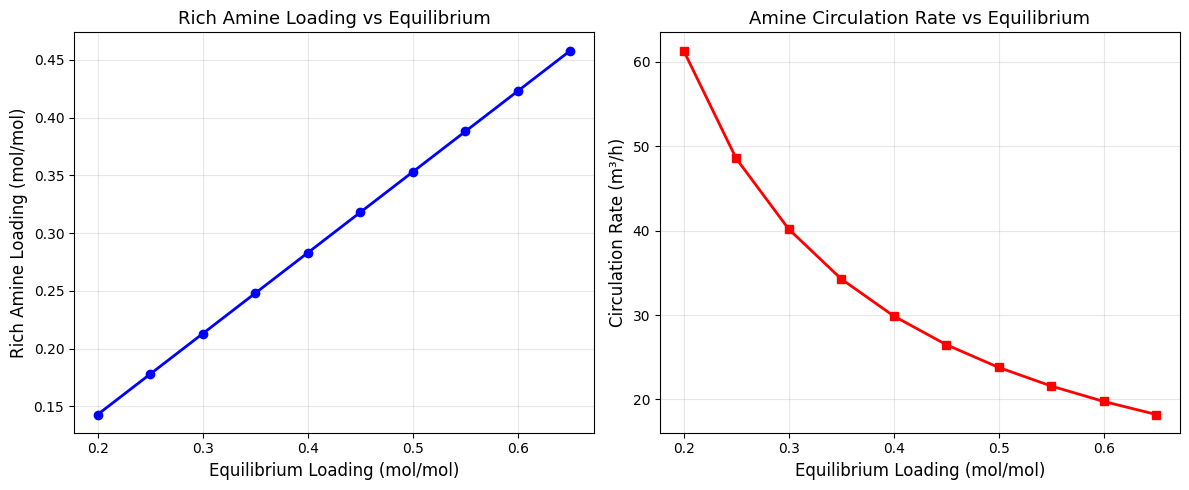

In [8]:
# Sensitivity: CO2 removal vs amine circulation rate
equilibrium_loadings = np.arange(0.20, 0.70, 0.05)
rich_loadings = []
circ_rates = []

for eq_load in equilibrium_loadings:
    amine_abs.setLeanAmineLoading(0.01)
    amine_abs.setApproachToEquilibrium(0.70)
    rl = float(amine_abs.calcRichAmineLoading(float(eq_load)))
    cr = float(amine_abs.calcRequiredCirculationRate(10.0, 1050.0, 0.119))
    rich_loadings.append(rl)
    circ_rates.append(cr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(equilibrium_loadings, rich_loadings, 'b-o', linewidth=2)
ax1.set_xlabel('Equilibrium Loading (mol/mol)', fontsize=12)
ax1.set_ylabel('Rich Amine Loading (mol/mol)', fontsize=12)
ax1.set_title('Rich Amine Loading vs Equilibrium', fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.plot(equilibrium_loadings, circ_rates, 'r-s', linewidth=2)
ax2.set_xlabel('Equilibrium Loading (mol/mol)', fontsize=12)
ax2.set_ylabel('Circulation Rate (m³/h)', fontsize=12)
ax2.set_title('Amine Circulation Rate vs Equilibrium', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:** As the equilibrium loading increases, the rich amine loading increases linearly (limited by the 70% approach to equilibrium). Higher equilibrium loading means lower amine circulation rates — the amine can pick up more acid gas per unit volume.

**Engineering implication:** Selecting an amine with higher equilibrium capacity (e.g., MDEA over MEA for CO2-selective removal) reduces the required circulation rate and regeneration energy.

## 3. Gas Flotation Unit (IGF/DGF)

Gas flotation units remove dispersed oil from produced water by injecting fine gas bubbles
that attach to oil droplets, floating them to the surface for skimming.

In [9]:
# Produced water stream
pw_fluid = SystemSrkEos(273.15 + 60.0, 5.0)
pw_fluid.addComponent("water", 0.99)
pw_fluid.addComponent("n-heptane", 0.01)
pw_fluid.setMixingRule("classic")

pw_stream = Stream("Produced Water", pw_fluid)
pw_stream.setFlowRate(250.0, "m3/hr")

# Gas Flotation Unit
igf = GasFlotationUnit("IGF-100", pw_stream)
igf.setNumberOfStages(4)
igf.setOilRemovalEfficiency(0.90)
igf.setInletOilConcentration(200.0)  # mg/L from upstream hydrocyclone
igf.setWaterFlowRate(250.0)          # m3/h

process3 = ProcessSystem()
process3.add(pw_stream)
process3.add(igf)
process3.run()

per_stage_eff = float(igf.calcPerStageEfficiency())
min_gas = float(igf.calcMinimumGasFlowRate())
reject_per_stage = float(igf.calcRejectFlowPerStage())
total_reject = float(igf.getTotalRejectFlow())
outlet_oil = float(igf.getOutletOilMgL())

print(f"Outlet OIW:          {outlet_oil:.1f} mg/L (inlet: 200 mg/L)")
print(f"Per-stage efficiency: {per_stage_eff*100:.1f}%")
print(f"Overall efficiency:   {float(igf.getOilRemovalEfficiency())*100:.0f}%")
print(f"Min gas flow:         {min_gas:.1f} Am3/h")
print(f"Reject per stage:     {reject_per_stage:.1f} m3/h")
print(f"Total reject:         {total_reject:.1f} m3/h")
print(f"\nCompliance: {'PASS (< 30 mg/L)' if outlet_oil <= 30 else 'FAIL (> 30 mg/L)'}")

Outlet OIW:          20.0 mg/L (inlet: 200 mg/L)
Per-stage efficiency: 43.8%
Overall efficiency:   90%
Min gas flow:         25.0 Am3/h
Reject per stage:     5.0 m3/h
Total reject:         20.0 m3/h

Compliance: PASS (< 30 mg/L)


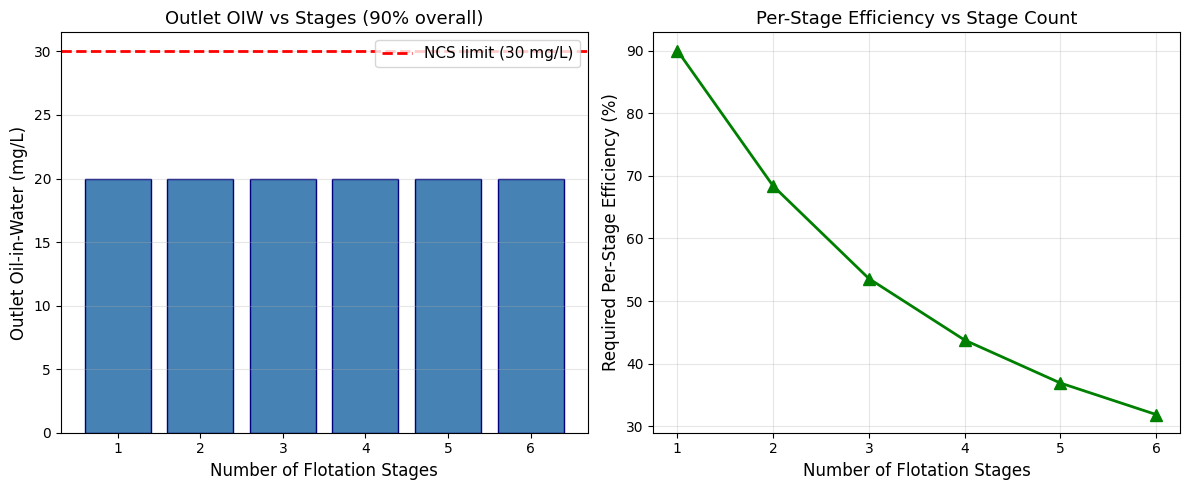

In [10]:
# Sensitivity: outlet OIW vs number of stages
stages_range = range(1, 7)
outlet_oil_vs_stages = []
per_stage_eff_vs_stages = []

for n_stages in stages_range:
    igf_test = GasFlotationUnit("IGF-test")
    igf_test.setNumberOfStages(n_stages)
    igf_test.setOilRemovalEfficiency(0.90)
    igf_test.setInletOilConcentration(200.0)
    igf_test.setWaterFlowRate(250.0)
    igf_test.run()
    outlet_oil_vs_stages.append(float(igf_test.getOutletOilMgL()))
    per_stage_eff_vs_stages.append(float(igf_test.calcPerStageEfficiency()) * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(list(stages_range), outlet_oil_vs_stages, color='steelblue', edgecolor='navy')
ax1.axhline(y=30, color='red', linestyle='--', linewidth=2, label='NCS limit (30 mg/L)')
ax1.set_xlabel('Number of Flotation Stages', fontsize=12)
ax1.set_ylabel('Outlet Oil-in-Water (mg/L)', fontsize=12)
ax1.set_title('Outlet OIW vs Stages (90% overall)', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

ax2.plot(list(stages_range), per_stage_eff_vs_stages, 'g-^', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Flotation Stages', fontsize=12)
ax2.set_ylabel('Required Per-Stage Efficiency (%)', fontsize=12)
ax2.set_title('Per-Stage Efficiency vs Stage Count', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:** The outlet OIW is the same (20 mg/L) for all configurations at 90% overall removal, but fewer stages demand a higher per-stage efficiency. With 1 stage, a single unit must achieve 90%: unrealistic for flotation. With 4 stages, each needs only ~44%.

**Engineering implication:** 3–4 stages is the practical range. Fewer stages require unrealistically high per-stage performance; more stages add cost without benefit if the overall target is fixed.

## 4. Hydrocyclone Design Validation

Hydrocyclones require adequate differential pressure for separation. Efficiency depends on dP and temperature.

In [11]:
# Create and configure hydrocyclone
hc_fluid = SystemSrkEos(273.15 + 65.0, 8.0)
hc_fluid.addComponent("water", 0.98)
hc_fluid.addComponent("n-heptane", 0.02)
hc_fluid.setMixingRule("classic")

hc_stream = Stream("HC Feed", hc_fluid)
hc_stream.setFlowRate(300.0, "m3/hr")

hc = Hydrocyclone("HC-100", hc_stream)
hc.setD50Microns(12.0)
hc.setRejectRatio(0.02)
hc.setPressureDropBar(3.5)
hc.setOilRemovalEfficiency(0.95)
hc.setInletOilConcentration(800.0)

process4 = ProcessSystem()
process4.add(hc_stream)
process4.add(hc)
process4.run()

dp_ok = bool(hc.isDifferentialPressureAdequate())
outlet_oil_hc = float(hc.getOutletOilMgL())
required_inlet = float(hc.calcRequiredInletPressure(5.0, 0.5, 0.3, 0.2))

print(f"Pressure drop:       {float(hc.getPressureDropBar()):.1f} bar")
print(f"dP adequate:         {dp_ok} (min 2.0 bar)")
print(f"Inlet OIW:           800 mg/L")
print(f"Outlet OIW:          {outlet_oil_hc:.0f} mg/L")
print(f"Required inlet P:    {required_inlet:.1f} bar")
print()
print(str(hc.getDesignValidationSummary()))

Pressure drop:       3.5 bar
dP adequate:         True (min 2.0 bar)
Inlet OIW:           800 mg/L
Outlet OIW:          40 mg/L
Required inlet P:    9.5 bar

Hydrocyclone Design Validation
d50 cut size: 12.0 microns
Pressure drop: 3.5 bar (min: 2.0, recommended: 5.0)
dP adequate: OK
Reject ratio: 2.0%
Oil removal efficiency: 95.0%
Inlet OIW: 800 mg/L
Outlet OIW: 40 mg/L



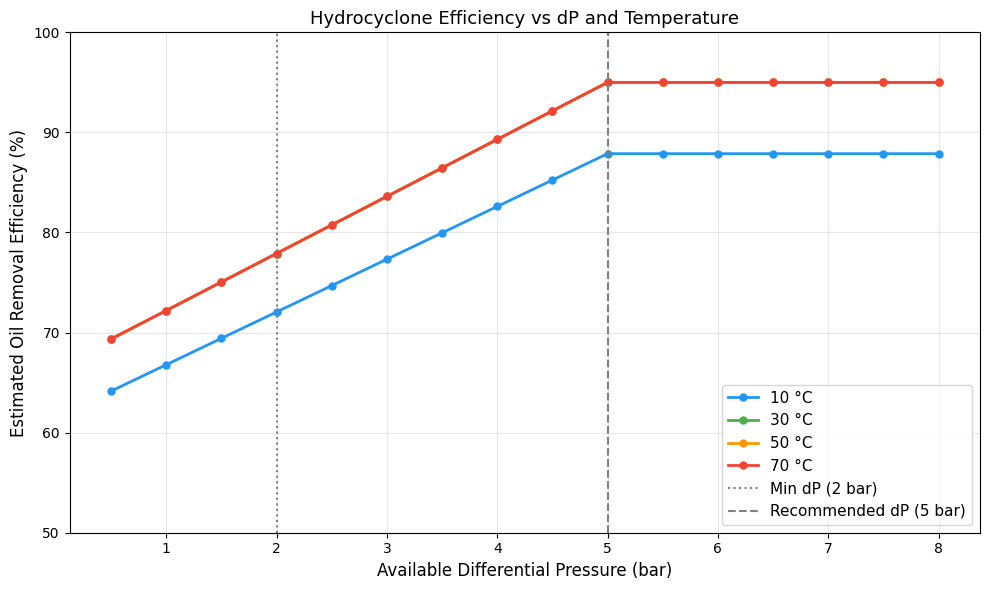

In [12]:
# Sensitivity: efficiency vs dP at different temperatures
dp_range = np.arange(0.5, 8.5, 0.5)
temps = [10, 30, 50, 70]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(10, 6))

for temp, color in zip(temps, colors):
    effs = [float(hc.estimateEfficiencyFromConditions(float(dp), float(temp))) * 100
            for dp in dp_range]
    ax.plot(dp_range, effs, '-o', color=color, linewidth=2, markersize=5,
            label=f'{temp} °C')

ax.axvline(x=2.0, color='gray', linestyle=':', linewidth=1.5, label='Min dP (2 bar)')
ax.axvline(x=5.0, color='gray', linestyle='--', linewidth=1.5, label='Recommended dP (5 bar)')
ax.set_xlabel('Available Differential Pressure (bar)', fontsize=12)
ax.set_ylabel('Estimated Oil Removal Efficiency (%)', fontsize=12)
ax.set_title('Hydrocyclone Efficiency vs dP and Temperature', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(50, 100)
plt.tight_layout()
plt.show()

**Observation:** Efficiency improves with increasing dP up to the recommended 5 bar, beyond which gains are marginal. Cold water (10°C) gives significantly lower efficiency than warm water (50–70°C) due to increased oil viscosity.

**Engineering implication:** Ensure at least 5 bar dP is available for good turndown. In cold-climate operations, water pre-heating should be considered if hydrocyclone performance is marginal.

## 5. Erosion Sand Load Defaults

The `ErosionPredictionCalculator` provides default sand production parameters based on well completion type for screening-level erosion assessments.

In [13]:
# List all available completion types
calc = ErosionPredictionCalculator()
completion_types = list(ErosionPredictionCalculator.getAvailableCompletionTypes())

print(f"{'Completion Type':<20} {'Liquid ppm':<12} {'Gas ppm':<10} {'Particle (μm)':<14} {'Description'}")
print("-" * 95)

for ct in completion_types:
    defaults = ErosionPredictionCalculator.getSandLoadDefaults(ct)
    print(f"{ct:<20} {float(defaults.getLiquidPpmWt()):<12.1f} {float(defaults.getGasPpmWt()):<10.2f} "
          f"{float(defaults.getParticleSizeMicrons()):<14.0f} {str(defaults.getCompletionType())}")

Completion Type      Liquid ppm   Gas ppm    Particle (μm)  Description
-----------------------------------------------------------------------------------------------
natural              1.0          0.05       250            Natural completion (no mechanical failure predicted)
natural_failure      10.0         0.50       250            Natural completion (mechanical failure predicted)
sas                  3.0          0.30       100            SAS or OHGP with incomplete packs
ohgp_incomplete      3.0          0.30       100            SAS or OHGP with incomplete packs
ohgp_complete        1.0          0.05       50             OHGP with 100% packing efficiency


In [14]:
# Apply defaults and calculate sand rate for a production well
calc = ErosionPredictionCalculator()

# Well producing 500 m3/day liquid + 100,000 kg/day gas
liquid_rate = 500.0    # m3/day
gas_rate = 100000.0    # kg/day
liquid_density = 850.0 # kg/m3

print(f"Production: {liquid_rate:.0f} m3/day liquid, {gas_rate:.0f} kg/day gas")
print(f"{'='*70}")
print(f"{'Completion':<22} {'Sand Rate (kg/day)':<20} {'Particle (mm)'}")
print(f"{'-'*70}")

sand_rates_by_type = {}
for ct in completion_types:
    c = ErosionPredictionCalculator()
    c.applySandLoadDefaults(ct, liquid_rate, gas_rate, liquid_density)
    sr = float(c.getSandRate())
    pd = float(c.getSandParticleDiameter())
    sand_rates_by_type[ct] = sr
    print(f"{ct:<22} {sr:<20.3f} {pd:.3f}")

# Corrosion-limited velocities
print(f"\n{'='*70}")
calc.setMixtureDensity(150.0)
v_inhibited_no_sand = float(calc.calcMaxVelocityForCorrosionProtection(True, False))
v_inhibited_sand = float(calc.calcMaxVelocityForCorrosionProtection(True, True))
v_uninhibited = float(calc.calcMaxVelocityForCorrosionProtection(False, False))
print(f"Max velocity (inhibited, no sand):  {v_inhibited_no_sand:.1f} m/s")
print(f"Max velocity (inhibited, with sand): {v_inhibited_sand:.1f} m/s")
print(f"Max velocity (uninhibited):          {v_uninhibited:.1f} m/s")

Production: 500 m3/day liquid, 100000 kg/day gas
Completion             Sand Rate (kg/day)   Particle (mm)
----------------------------------------------------------------------
natural                0.425                0.250
natural_failure        4.250                0.250
sas                    1.275                0.100
ohgp_incomplete        1.275                0.100
ohgp_complete          0.425                0.050

Max velocity (inhibited, no sand):  14.9 m/s
Max velocity (inhibited, with sand): 11.2 m/s
Max velocity (uninhibited):          10.0 m/s


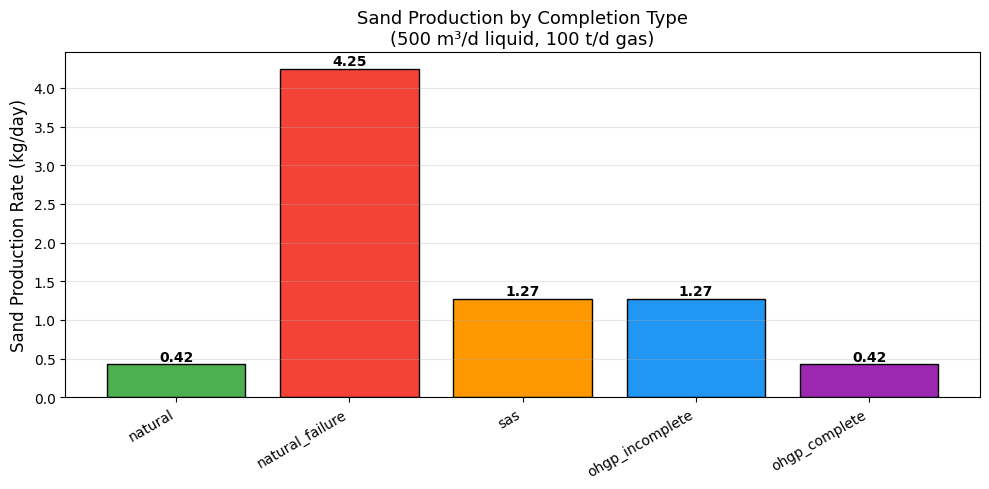

In [15]:
# Plot: sand rate comparison by completion type
fig, ax = plt.subplots(figsize=(10, 5))

labels = list(sand_rates_by_type.keys())
values = list(sand_rates_by_type.values())
bar_colors = ['#4CAF50', '#F44336', '#FF9800', '#2196F3', '#9C27B0']

bars = ax.bar(range(len(labels)), values, color=bar_colors[:len(labels)], edgecolor='black')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Sand Production Rate (kg/day)', fontsize=12)
ax.set_title('Sand Production by Completion Type\n(500 m³/d liquid, 100 t/d gas)', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Observation:** Sand production rates vary by an order of magnitude across completion types. "Natural with failure" produces ~4.25 kg/day — 8x more than OHGP with complete packing (0.43 kg/day). SAS/OHGP incomplete is intermediate at ~1.28 kg/day.

**Engineering implication:** Completion type has a major impact on erosion risk. Wells with predicted mechanical failure need aggressive sand management (desanders, erosion-resistant materials, reduced velocities). OHGP completions with good packing efficiency allow higher operating velocities.

## Summary

| Feature | Class | Key Methods |
|---------|-------|-------------|
| TEG Fs-factor | `SimpleTEGAbsorber` | `getFsFactor()`, `isFsFactorWithinDesignLimit()`, `validateContactorDesign()` |
| Amine sweetening | `SimpleAmineAbsorber` | `setCO2RemovalEfficiency()`, `calcRichAmineLoading()`, `validateDesign()` |
| Gas flotation | `GasFlotationUnit` | `calcPerStageEfficiency()`, `calcMinimumGasFlowRate()`, `calcRejectFlowPerStage()` |
| Hydrocyclone dP | `Hydrocyclone` | `isDifferentialPressureAdequate()`, `estimateEfficiencyFromConditions()` |
| Sand load defaults | `ErosionPredictionCalculator` | `getSandLoadDefaults()`, `applySandLoadDefaults()`, `calcMaxVelocityForCorrosionProtection()` |

All equipment integrates with `ProcessSystem` for flowsheet simulation.
See the [absorbers documentation](../../docs/process/equipment/absorbers.md),
[water treatment documentation](../../docs/process/equipment/water_treatment.md),
and [erosion prediction documentation](../../docs/pvtsimulation/flowassurance/erosion_prediction.md)
for complete API reference.